## Import relevant libraries

In [236]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction import DictVectorizer
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

from sklearn.metrics import root_mean_squared_error as rmse

## Download the file

In [14]:
link = 'https://github.com/alexeygrigorev/datasets/raw/refs/heads/master/jamb_exam_results.csv'
# Download to specific folder
!wget $link -P data/

--2024-10-28 10:35:33--  https://github.com/alexeygrigorev/datasets/raw/refs/heads/master/jamb_exam_results.csv
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/alexeygrigorev/datasets/refs/heads/master/jamb_exam_results.csv [following]
--2024-10-28 10:35:34--  https://raw.githubusercontent.com/alexeygrigorev/datasets/refs/heads/master/jamb_exam_results.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 391501 (382K) [text/plain]
Saving to: 'data/jamb_exam_results.csv.1'

     0K .......... .......... .......... .......... .......... 13% 1,42M 0s
    50K .......... .......... .......... ....

## Load the dataset

In [19]:
df = pd.read_csv('data/jamb_exam_results.csv')
df.head()

,JAMB_Score,Study_Hours_Per_Week,Attendance_Rate,Teacher_Quality,Distance_To_School,School_Type,School_Location,Extra_Tutorials,Access_To_Learning_Materials,Parent_Involvement,IT_Knowledge,Student_ID,Age,Gender,Socioeconomic_Status,Parent_Education_Level,Assignments_Completed
0,192,22,78,4,12.4,Public,Urban,Yes,Yes,High,Medium,1,17,Male,Low,Tertiary,2
1,207,14,88,4,2.7,Public,Rural,No,Yes,High,High,2,15,Male,High,NaN,1
2,182,29,87,2,9.6,Public,Rural,Yes,Yes,High,Medium,3,20,Female,High,Tertiary,2
3,210,29,99,2,2.6,Public,Urban,No,Yes,Medium,High,4,22,Female,Medium,Tertiary,1
4,199,12,98,3,8.8,Public,Urban,No,Yes,Medium,Medium,5,22,Female,Medium,Tertiary,1


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   JAMB_Score                    5000 non-null   int64  
 1   Study_Hours_Per_Week          5000 non-null   int64  
 2   Attendance_Rate               5000 non-null   int64  
 3   Teacher_Quality               5000 non-null   int64  
 4   Distance_To_School            5000 non-null   float64
 5   School_Type                   5000 non-null   object 
 6   School_Location               5000 non-null   object 
 7   Extra_Tutorials               5000 non-null   object 
 8   Access_To_Learning_Materials  5000 non-null   object 
 9   Parent_Involvement            5000 non-null   object 
 10  IT_Knowledge                  5000 non-null   object 
 11  Student_ID                    5000 non-null   int64  
 12  Age                           5000 non-null   int64  
 13  Gen

In [27]:
df.isnull().sum()

JAMB_Score                        0
Study_Hours_Per_Week              0
Attendance_Rate                   0
Teacher_Quality                   0
Distance_To_School                0
School_Type                       0
School_Location                   0
Extra_Tutorials                   0
Access_To_Learning_Materials      0
Parent_Involvement                0
IT_Knowledge                      0
Student_ID                        0
Age                               0
Gender                            0
Socioeconomic_Status              0
Parent_Education_Level          891
Assignments_Completed             0
dtype: int64

## Preparing the dataset

- Lowercase column names
- Remove the `student_id` column.
- Fill missing values with zeros.
- Do train/validation/test split with 60%/20%/20% distribution.
- Use the `train_test_split` function and set the `random_state` parameter to 1.
- Use `DictVectorizer(sparse=True)` to turn the dataframes into matrices.

In [33]:
# lowering columns name
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [49]:
# Removing studend_id
del df['student_id']

In [53]:
# Filling missing value with 0
df = df.fillna(0)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   jamb_score                    5000 non-null   int64  
 1   study_hours_per_week          5000 non-null   int64  
 2   attendance_rate               5000 non-null   int64  
 3   teacher_quality               5000 non-null   int64  
 4   distance_to_school            5000 non-null   float64
 5   school_type                   5000 non-null   object 
 6   school_location               5000 non-null   object 
 7   extra_tutorials               5000 non-null   object 
 8   access_to_learning_materials  5000 non-null   object 
 9   parent_involvement            5000 non-null   object 
 10  it_knowledge                  5000 non-null   object 
 11  age                           5000 non-null   int64  
 12  gender                        5000 non-null   object 
 13  soc

In [59]:
# Splitting dataset
full_train, test = train_test_split(df, test_size=0.2, random_state=1)
train, val = train_test_split(full_train, test_size=0.25, random_state=1)

train = train.reset_index(drop=True)
val = val.reset_index(drop=True)
test = test.reset_index(drop=True)

In [61]:
y_train = train.jamb_score
y_val = val.jamb_score
y_test = test.jamb_score

del train['jamb_score']
del val['jamb_score']
del test['jamb_score']

In [68]:
# Use DictVectorizer
train_dict = train.to_dict(orient='records')

dv = DictVectorizer(sparse=True)
X_train = dv.fit_transform(train_dict)

## Q1: Train decision tree

In [72]:
dt = DecisionTreeRegressor(max_depth=1)
dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=1)

In [81]:
print(export_text(dt, feature_names=dv.get_feature_names_out()))

|--- study_hours_per_week <= 18.50
|   |--- value: [155.24]
|--- study_hours_per_week >  18.50
|   |--- value: [188.59]



feature used to splitting data is `study_hours_per_week`

## Q2: Train random forest model

In [110]:
rf = RandomForestRegressor(n_estimators=10, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=10, n_jobs=-1, random_state=1)

In [112]:
dict_val = val.to_dict(orient='records')

X_val = dv.transform(dict_val)

y_pred = rf.predict(X_val)

rmse(y_val, y_pred)

42.13724207871227

`RMSE` for the validation is `42.13`

## Q3: Fitting the best `n_estimators`

In [114]:
scores = []

for n in range(10, 201, 10):
    rf = RandomForestRegressor(n_estimators=n, random_state=1, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    y_pred = rf.predict(X_val)
    rmse_value = rmse(y_val, y_pred)

    scores.append([n, rmse_value)])

In [120]:
scores_df = pd.DataFrame(scores, columns=['n_estimators', 'rmse']) 
scores_df.rmse = scores_df.rmse.round(3)
scores_df

,n_estimators,rmse
0,10,42.137
1,20,41.461
2,30,41.106
3,40,40.917
4,50,40.852
5,60,40.784
6,70,40.677
7,80,40.539
8,90,40.504
9,100,40.517


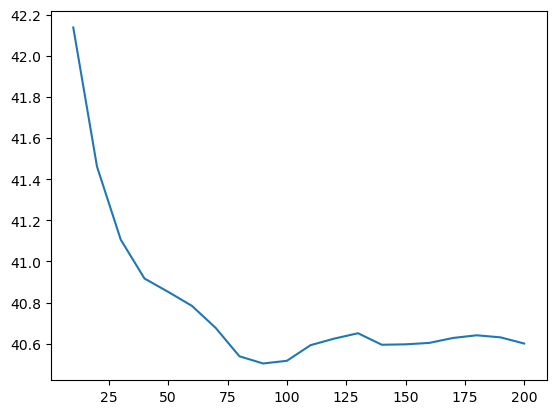

In [122]:
plt.plot(scores_df.n_estimators, scores_df.rmse)

The best n_estimators is around `80` & `90`

## Q4: Fitting the best `max_depth`

In [127]:
max_depths = [10, 15, 20, 25]

In [131]:
scores = []

for max_depth in max_depths:
    for n in range(10, 201, 10):
        rf = RandomForestRegressor(n_estimators=n, 
                                   max_depth=max_depth, 
                                   random_state=1, 
                                   n_jobs=-1)
        rf.fit(X_train, y_train)
        
        y_pred = rf.predict(X_val)
        rmse_value = rmse(y_val, y_pred)
    
        scores.append([max_depth, n, rmse_value])

scores_df = pd.DataFrame(scores, columns=['max_depth', 'n_estimators', 'rmse']) 
scores_df.rmse = scores_df.rmse.round(3)
scores_df

,max_depth,n_estimators,rmse
0,10,10,41.258
1,10,20,40.881
2,10,30,40.625
3,10,40,40.270
4,10,50,40.317
...,...,...,...
75,25,160,40.600
76,25,170,40.624
77,25,180,40.639
78,25,190,40.629


In [146]:
rmse_value = []

for d in max_depths:
    mean_rmse = np.mean(scores_df[scores_df.max_depth == d])
    rmse_value.append(mean_rmse.round(3))

rmse_value

[51.797, 53.578, 55.247, 56.929]

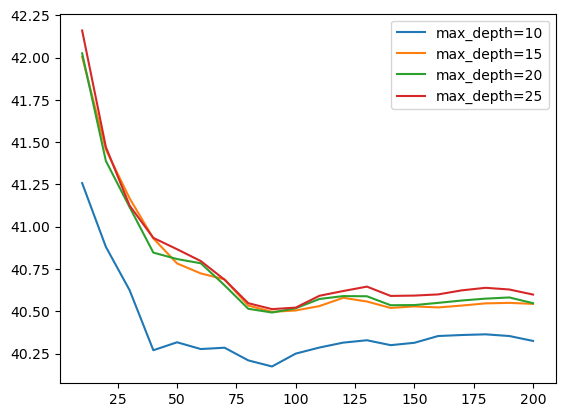

In [136]:
for d in max_depths:
    df_subset = scores_df[scores_df.max_depth == d]
    plt.plot(df_subset.n_estimators, df_subset.rmse, label='max_depth=%s' % d)

plt.legend()

Best max_depth is `10`

## Q5: Feature importance

In [155]:
rf = RandomForestRegressor(n_estimators=10,
                          max_depth=20,
                          random_state=1,
                          n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, n_estimators=10, n_jobs=-1, random_state=1)

In [230]:
feature_importance = pd.DataFrame(dv.get_feature_names_out(), columns=['feature'])
feature_importance['feature_importance'] = rf.feature_importances_
feature_importance.sort_values('feature_importance' ,ascending=False).reset_index(drop=True)

,feature,feature_importance
0,study_hours_per_week,0.248354
1,attendance_rate,0.149729
2,distance_to_school,0.136486
3,teacher_quality,0.082682
4,age,0.069311
5,assignments_completed,0.031517
6,socioeconomic_status=High,0.025714
7,parent_involvement=High,0.022919
8,it_knowledge=High,0.017719
9,parent_education_level=Secondary,0.016957


The highest `feature_importance` value is `study_hours_per_week` with value `0.248`

## Q6: Training XGBoost

In [238]:
features = dv.get_feature_names_out()
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=list(features))
dval = xgb.DMatrix(X_val, feature_names=list(features))

In [249]:
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=100)

y_pred = model.predict(dval)
rmse(y_val, y_pred).round(3)

43.419

In [251]:
xgb_params = {
    'eta': 0.1, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=100)

y_pred = model.predict(dval)
rmse(y_val, y_pred).round(3)

41.05

Best `RMSE` is with `eta = 0.1` with value `41.05` rather than `eta = 0.3` with value `43.419`